# Part B: Unsupervised Regime Detection

A Gaussian hidden Markov model (HMM) and K-means assign each trading day to one of three market regimes. Both methods use the logarithms of the 20-day realized volatility of the S&P 500 and of the VIX close. They are fitted to data from 2000 to 2017 and evaluated on data from 2018 to 2025. Only the HMM uses the order of the days, through a transition matrix (Rabiner, 1989).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

## Data and features

The 20-day window covers approximately one trading month, which is close to the 30-day horizon of the VIX. The log transformation reduces the skewness of both series in the training data.

In [2]:
df = pd.read_parquet('data/market_2000_2025.parquet').set_index('Date')
# daily log return of the S&P 500
df['ret'] = np.log(df['SP500_Close']).diff()
# annualized 20-day realized volatility from squared daily returns
df['rv20'] = np.sqrt(252 * (df['ret'] ** 2).rolling(20).mean())
df['log_rv20'] = np.log(df['rv20'])
df['log_vix'] = np.log(df['VIX_Close'])
df = df.dropna()

features = ['log_rv20', 'log_vix']
train = df.loc[:'2017-12-31']
test = df.loc['2018-01-01':]

print(pd.DataFrame({'start': [train.index[0].date(), test.index[0].date()],
                    'end': [train.index[-1].date(), test.index[-1].date()],
                    'days': [len(train), len(test)]}, index=['train', 'test']))
print(train[['rv20', 'VIX_Close', 'log_rv20', 'log_vix']].skew().round(2))

            start         end  days
train  2000-02-01  2017-12-29  4508
test   2018-01-02  2025-12-31  2011
rv20         2.74
VIX_Close    2.09
log_rv20     0.50
log_vix      0.66
dtype: float64


## Number of regimes

In [3]:
# fit the scaler on the training years only
scaler = StandardScaler().fit(train[features])
X_train = scaler.transform(train[features])
X_test = scaler.transform(test[features])
X_all = scaler.transform(df[features])
first_half = scaler.transform(train.loc[:'2008-12-31', features])
second_half = scaler.transform(train.loc['2009-01-01':, features])


def fit_hmm(n_states, X, n_starts=20):
    # keep the best of several EM runs because each run can stop at a local optimum
    best, best_ll = None, -np.inf
    for seed in range(2026, 2026 + n_starts):
        model = GaussianHMM(n_components=n_states, covariance_type='full', n_iter=1000, random_state=seed).fit(X)
        ll = model.score(X)
        if ll > best_ll:
            best, best_ll = model, ll
    return best


def fit_kmeans(n_clusters, X):
    return KMeans(n_clusters=n_clusters, n_init=10, random_state=2026).fit(X)


hmm_rows = []
for k in range(2, 7):
    model = fit_hmm(k, X_train)
    hmm_rows.append({'k': k,
                     'bic': model.bic(X_train),
                     # agreement between models fitted on the two halves of the training years
                     'split_half_ari': metrics.adjusted_rand_score(fit_hmm(k, first_half).predict(X_train),
                                                                   fit_hmm(k, second_half).predict(X_train)),
                     'vix_at_state_means': np.sort(np.exp(scaler.inverse_transform(model.means_)[:, 1])).round(1)})
print(pd.DataFrame(hmm_rows).set_index('k').round(3))

km_rows = []
for k in range(2, 7):
    km = fit_kmeans(k, X_train)
    km_rows.append({'k': k,
                    'inertia': km.inertia_,
                    'silhouette': metrics.silhouette_score(X_train, km.labels_),
                    'davies_bouldin': metrics.davies_bouldin_score(X_train, km.labels_),
                    'calinski_harabasz': metrics.calinski_harabasz_score(X_train, km.labels_),
                    'split_half_ari': metrics.adjusted_rand_score(fit_kmeans(k, first_half).predict(X_train),
                                                                  fit_kmeans(k, second_half).predict(X_train))})
print(pd.DataFrame(km_rows).set_index('k').round(3))

         bic  split_half_ari                    vix_at_state_means
k                                                                 
2  13678.420           0.844                          [14.0, 25.4]
3  10862.765           0.705                    [12.2, 16.9, 27.3]
4   8699.642           0.410              [12.1, 15.7, 20.7, 29.7]
5   7140.148           0.513        [12.1, 15.6, 19.1, 24.2, 35.3]
6   5961.087           0.489  [11.4, 13.2, 15.8, 20.1, 24.8, 35.0]


    inertia  silhouette  davies_bouldin  calinski_harabasz  split_half_ari
k                                                                         
2  3348.151       0.539           0.644           7627.889           0.922
3  2098.695       0.452           0.707           7424.758           0.304
4  1419.490       0.429           0.737           8034.622           0.333
5  1127.575       0.390           0.781           7875.702           0.557
6   951.968       0.368           0.830           7627.294           0.460


BIC decreases monotonically from K = 2 to K = 6, and each additional HMM state divides the VIX range more finely. Information criteria often select too many states when each state is meant to have a clear interpretation, and the choice then also depends on the aim of the study (Pohle et al., 2017). The split-half ARI (von Luxburg, 2010) compares the labels given to the training days by models fitted on 2000 to 2008 and on 2009 to 2017. Because the two halves are consecutive periods, a low value may also reflect a change in market conditions between them. The split-half ARI is highest at K = 2 for both methods. For the HMM it falls from 0.705 at K = 3 to 0.410 at K = 4, and for K-means it is lowest at K = 3 (0.304). At K = 2 the HMM states separate only high and low volatility (VIX 14.0 and 25.4 at the state means). Both methods use K = 3 so that the regimes separate calm, transitional and stressed market conditions.

## Final models

In [4]:
names = ['Calm', 'Transitional', 'Stressed']
hmm = fit_hmm(3, X_train)
km = fit_kmeans(3, X_train)

# sort states by mean log VIX so that 0 is calm and 2 is stressed
hmm_order = np.argsort(hmm.means_[:, 1])
km_order = np.argsort(km.cluster_centers_[:, 1])
# Viterbi decoding gives the most likely regime path
df['hmm'] = np.argsort(hmm_order)[hmm.predict(X_all)]
df['kmeans'] = np.argsort(km_order)[km.predict(X_all)]
trans = pd.DataFrame(hmm.transmat_[np.ix_(hmm_order, hmm_order)], index=names, columns=names)

# state covariances converted from standardized units back to log units
cov = hmm.covars_[hmm_order] * np.outer(scaler.scale_, scaler.scale_)
means = scaler.inverse_transform(hmm.means_[hmm_order])
print(pd.DataFrame({'vix_at_mean': np.exp(means[:, 1]),
                    'rv20_pct_at_mean': np.exp(means[:, 0]) * 100,
                    'sd_log_vix': np.sqrt(cov[:, 1, 1]),
                    'sd_log_rv20': np.sqrt(cov[:, 0, 0]),
                    'corr_log_rv20_log_vix': cov[:, 0, 1] / np.sqrt(cov[:, 0, 0] * cov[:, 1, 1]),
                    'expected_duration_days': 1 / (1 - np.diag(trans))}, index=names).rename_axis('HMM state').round(3))

centers = np.exp(scaler.inverse_transform(km.cluster_centers_[km_order]))
print(pd.DataFrame({'vix_at_center': centers[:, 1], 'rv20_pct_at_center': centers[:, 0] * 100},
                   index=names).rename_axis('K-means cluster').round(2))

              vix_at_mean  rv20_pct_at_mean  sd_log_vix  sd_log_rv20  corr_log_rv20_log_vix  expected_duration_days
HMM state                                                                                                          
Calm               12.208             8.280       0.109        0.234                  0.468                  49.666
Transitional       16.916            12.403       0.136        0.219                  0.033                  38.351
Stressed           27.325            23.914       0.261        0.353                  0.806                  95.824
                 vix_at_center  rv20_pct_at_center
K-means cluster                                   
Calm                     13.40                9.11
Transitional             20.45               16.41
Stressed                 33.37               31.31


## Regime profiles by period

From the training period to the test period, the mean VIX of each regime changes by less than 2 points and the mean realized volatility by less than 1.1 percentage points.

In [5]:
def regime_profile(data, col):
    labels = data[col]
    runs = labels.ne(labels.shift()).cumsum()
    run_days = labels.groupby(runs).agg(['first', 'size']).groupby('first')['size'].mean()
    g = data.groupby(col)
    return pd.DataFrame({'share_of_days': g.size() / len(data),
                         'mean_vix': g['VIX_Close'].mean(),
                         'mean_rv20_pct': g['rv20'].mean() * 100,
                         'mean_duration_days': run_days}).rename(index=dict(enumerate(names)))


print(pd.concat({(m, period): regime_profile(df.loc[idx], col)
                 for m, col in [('HMM', 'hmm'), ('K-means', 'kmeans')]
                 for period, idx in [('train', train.index), ('test', test.index)]}).round(2))

                            share_of_days  mean_vix  mean_rv20_pct  mean_duration_days
HMM     train Calm                   0.27     12.25           8.48               51.50
              Transitional           0.36     17.05          12.66               41.79
              Stressed               0.36     28.38          25.69              102.62
        test  Calm                   0.20     13.01           8.85               30.46
              Transitional           0.45     17.41          12.36               38.96
              Stressed               0.36     26.40          25.45               65.36
K-means train Calm                   0.45     13.59           9.40               27.63
              Transitional           0.38     20.76          16.81               14.69
              Stressed               0.17     34.51          33.28               16.82
        test  Calm                   0.40     14.48           9.70               18.74
              Transitional           0.46  

## S&P 500 by regime

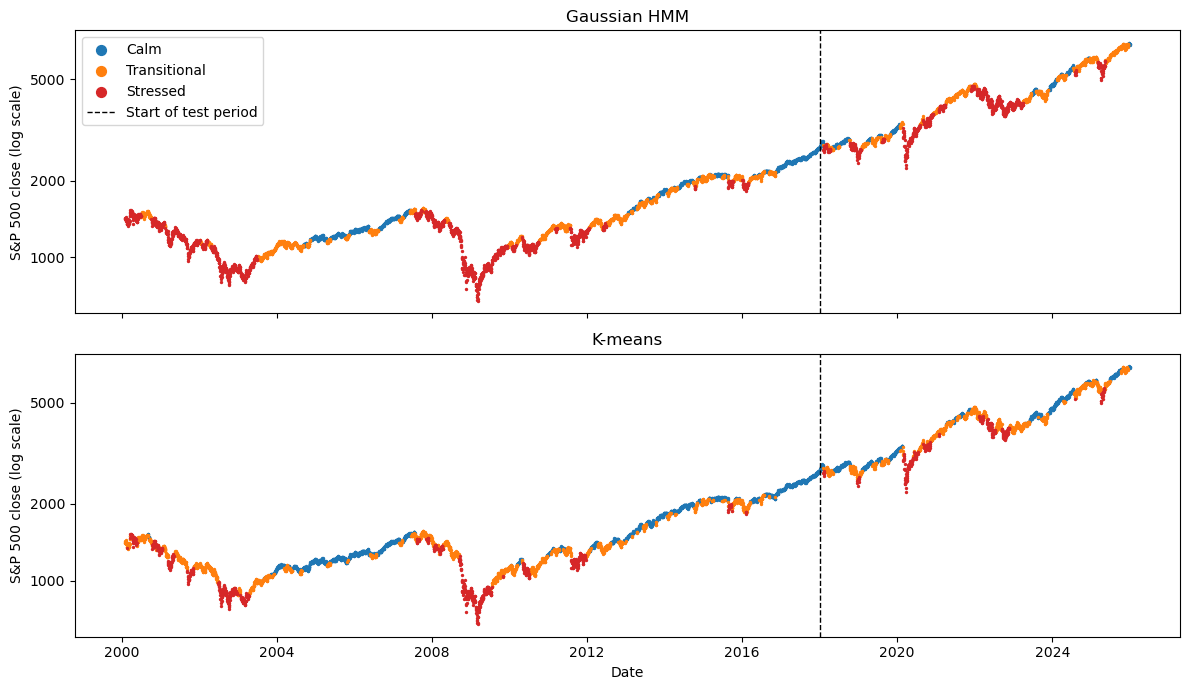

      SP500_year_end  HMM Calm  HMM Transitional  HMM Stressed  K-means Calm  K-means Transitional  K-means Stressed
year                                                                                                                
2000         1320.28      0.00              0.30          0.70          0.05                  0.63              0.32
2001         1148.08      0.00              0.04          0.96          0.00                  0.64              0.36
2002          879.82      0.00              0.16          0.84          0.00                  0.55              0.45
2003         1111.92      0.00              0.52          0.48          0.16                  0.63              0.21
2004         1211.92      0.24              0.76          0.00          0.80                  0.20              0.00
2005         1248.29      0.80              0.20          0.00          0.92                  0.08              0.00
2006         1418.30      0.75              0.25          0.00  

In [6]:
colors = ['tab:blue', 'tab:orange', 'tab:red']
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, col, title in zip(axes, ['hmm', 'kmeans'], ['Gaussian HMM', 'K-means']):
    for s in range(3):
        d = df[df[col] == s]
        ax.scatter(d.index, d['SP500_Close'], s=2, color=colors[s], label=names[s])
    ax.axvline(test.index[0], color='black', linestyle='--', linewidth=1, label='Start of test period')
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(mticker.LogLocator(subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.set_ylabel('S&P 500 close (log scale)')
    ax.set_title(title)
axes[0].legend(markerscale=5, loc='upper left')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

yearly = pd.concat({'HMM': pd.crosstab(df.index.year, df['hmm'], normalize='index'),
                    'K-means': pd.crosstab(df.index.year, df['kmeans'], normalize='index')}, axis=1)
yearly.columns = [f'{m} {names[s]}' for m, s in yearly.columns]
yearly.insert(0, 'SP500_year_end', df['SP500_Close'].groupby(df.index.year).last())
print(yearly.rename_axis('year').round(2))

## Transition probabilities

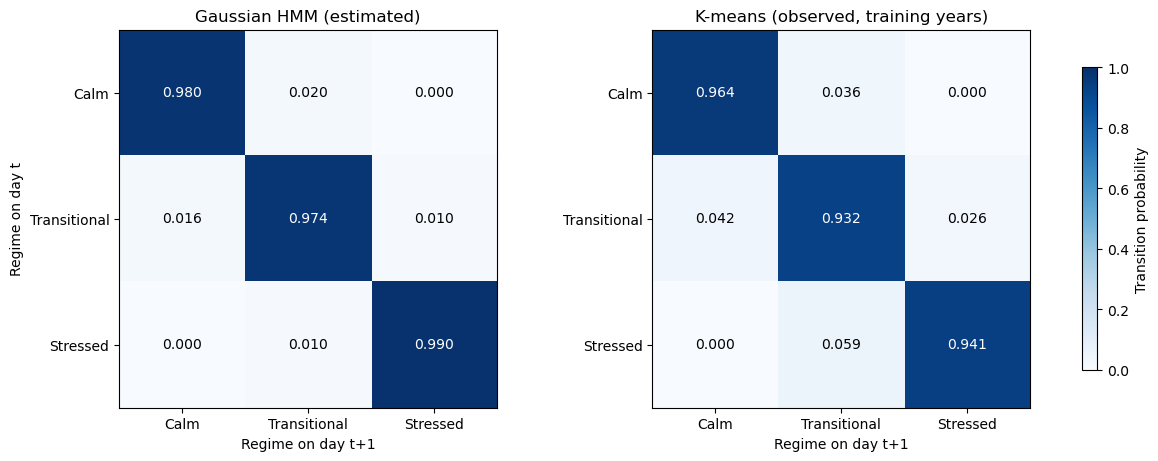

                        Calm  Transitional  Stressed
HMM     Calm          0.9799        0.0201    0.0000
        Transitional  0.0161        0.9739    0.0099
        Stressed      0.0000        0.0104    0.9896
K-means Calm          0.9643        0.0357    0.0000
        Transitional  0.0421        0.9319    0.0260
        Stressed      0.0000        0.0594    0.9406


In [7]:
km_path = df.loc[train.index, 'kmeans'].to_numpy()
km_trans = pd.crosstab(km_path[:-1], km_path[1:], normalize='index').set_axis(names).set_axis(names, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for ax, mat, title in zip(axes, [trans, km_trans], ['Gaussian HMM (estimated)', 'K-means (observed, training years)']):
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat.iloc[i, j]:.3f}', ha='center', va='center',
                    color='white' if mat.iloc[i, j] > 0.5 else 'black')
    ax.set_xticks(range(3), names)
    ax.set_yticks(range(3), names)
    ax.set_xlabel('Regime on day t+1')
    ax.set_title(title)
axes[0].set_ylabel('Regime on day t')
fig.colorbar(im, ax=axes, shrink=0.8, label='Transition probability')
plt.show()

print(pd.concat({'HMM': trans, 'K-means': km_trans}).round(4))

In both directions, the HMM probability of a direct move between the calm and stressed regimes rounds to 0.0000, and the K-means labels for 2000 to 2017 contain no such move.

## Market characteristics across regimes

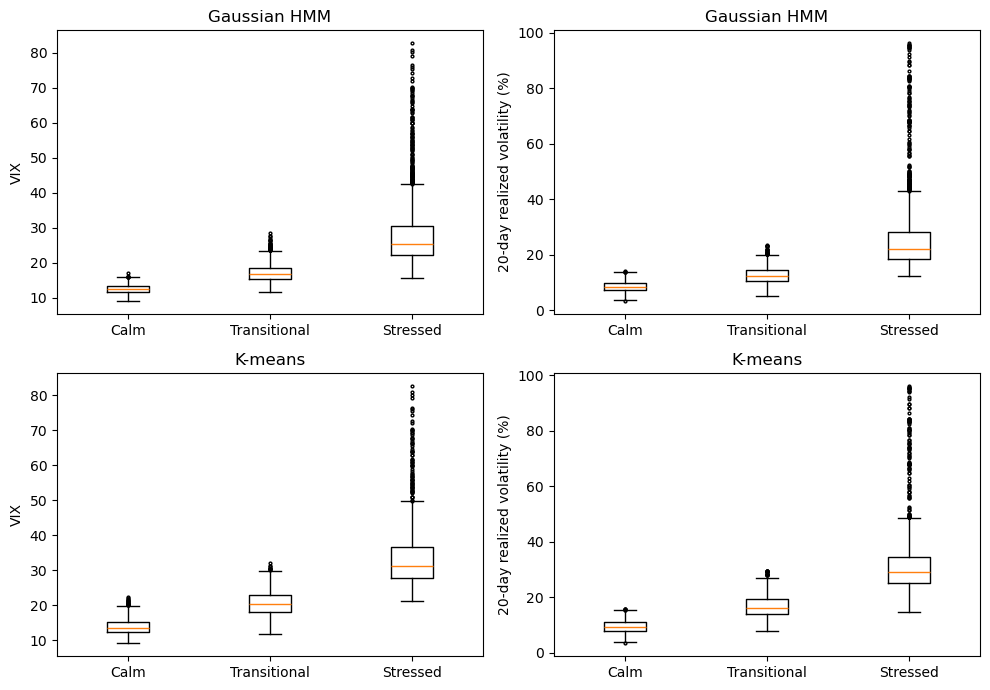

                                                       min  lower_whisker     q1  median     q3  upper_whisker    max  n_low_outliers  n_high_outliers
HMM     Calm         VIX                              9.14           9.14  11.57   12.51  13.31          15.86  17.02               0                6
                     20-day realized volatility (%)   3.38           3.74   7.31    8.45   9.88          13.70  14.12               1                4
        Transitional VIX                             11.77          11.77  15.37   16.81  18.62          23.45  28.62               0               36
                     20-day realized volatility (%)   5.02           5.02  10.57   12.46  14.38          19.95  23.34               0               24
        Stressed     VIX                             15.80          15.80  22.23   25.41  30.39          42.63  82.69               0              148
                     20-day realized volatility (%)  12.33          12.33  18.53   22.17  28.3

In [8]:
variables = [('VIX_Close', 1, 'VIX'), ('rv20', 100, '20-day realized volatility (%)')]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for i, (col, title) in enumerate([('hmm', 'Gaussian HMM'), ('kmeans', 'K-means')]):
    for j, (var, scale, label) in enumerate(variables):
        ax = axes[i, j]
        ax.boxplot([df.loc[df[col] == s, var] * scale for s in range(3)], tick_labels=names, flierprops={'markersize': 2})
        ax.set_ylabel(label)
        ax.set_title(title)
plt.tight_layout()
plt.show()


def box_stats(x):
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({'min': x.min(), 'lower_whisker': x[x >= low].min(), 'q1': q1, 'median': q2, 'q3': q3,
                      'upper_whisker': x[x <= high].max(), 'max': x.max(),
                      'n_low_outliers': (x < low).sum(), 'n_high_outliers': (x > high).sum()})


box = {(m, names[s], label): box_stats(df.loc[df[col] == s, var] * scale)
       for m, col in [('HMM', 'hmm'), ('K-means', 'kmeans')] for s in range(3) for var, scale, label in variables}
print(pd.DataFrame(box).T.astype({'n_low_outliers': int, 'n_high_outliers': int}).round(2))

## Clustering quality and agreement

In [9]:
quality = {}
for m, col in [('HMM', 'hmm'), ('K-means', 'kmeans')]:
    row = {}
    for period, X, idx in [('train', X_train, train.index), ('test', X_test, test.index)]:
        labels = df.loc[idx, col]
        row[f'silhouette_{period}'] = metrics.silhouette_score(X, labels)
        row[f'davies_bouldin_{period}'] = metrics.davies_bouldin_score(X, labels)
        row[f'calinski_harabasz_{period}'] = metrics.calinski_harabasz_score(X, labels)
    row['switches_per_year'] = np.count_nonzero(np.diff(df[col])) / (len(df) / 252)
    quality[m] = row
print(pd.DataFrame(quality).round(3))
print('ARI between HMM and K-means:', round(metrics.adjusted_rand_score(df['hmm'], df['kmeans']), 3))
print(pd.crosstab(df['hmm'].map(dict(enumerate(names))), df['kmeans'].map(dict(enumerate(names))),
                  rownames=['HMM'], colnames=['K-means']).loc[names, names])

                              HMM   K-means
silhouette_train            0.394     0.452
davies_bouldin_train        0.792     0.707
calinski_harabasz_train  6101.300  7424.758
silhouette_test             0.331     0.407
davies_bouldin_test         0.896     0.793
calinski_harabasz_test   1859.313  2415.363
switches_per_year           4.793    13.955
ARI between HMM and K-means: 0.32
K-means       Calm  Transitional  Stressed
HMM                                       
Calm          1631             1         0
Transitional  1192          1334         0
Stressed         0          1321      1040


K-means obtains better silhouette, Davies-Bouldin and Calinski-Harabasz values in both periods. These measures give better values for compact, well-separated clusters, and K-means minimizes the within-cluster sum of squares. The HMM labels change 4.8 times per year and the K-means labels 14.0 times per year. No day is labeled calm by one method and stressed by the other.

## Stress periods

Within 2007 to 2009 and within 2020, each window ends at the lowest S&P 500 close and starts at the highest close before that date. The 2008 window lies in the training period and the 2020 window in the test period.

In [10]:
events = {'2008 financial crisis': ('2007', '2009'), '2020 COVID shock': ('2020', '2020')}
rows = []
for event, (start, end) in events.items():
    close = df.loc[start:end, 'SP500_Close']
    trough = close.idxmin()
    peak = close.loc[:trough].idxmax()
    window = df.loc[peak:trough]
    after = df.loc[trough:]
    for m, col in [('HMM', 'hmm'), ('K-means', 'kmeans')]:
        stressed = window[col] == 2
        first = stressed.idxmax() if stressed.any() else None
        # first day on or after the trough that is not in the stressed regime
        calmer = after[col] != 2
        leave = calmer.idxmax() if calmer.any() else None
        rows.append({'event': event, 'peak': peak.date(), 'trough': trough.date(), 'method': m,
                     'share_stressed': stressed.mean(),
                     'first_stressed_day': first.date() if first is not None else None,
                     'days_after_peak': window.index.get_loc(first) if first is not None else None,
                     'first_non_stressed_day': leave.date() if leave is not None else None,
                     'days_after_trough': after.index.get_loc(leave) if leave is not None else None})
print(pd.DataFrame(rows).set_index(['event', 'method']).round(3))

                                     peak      trough  share_stressed first_stressed_day  days_after_peak first_non_stressed_day  days_after_trough
event                 method                                                                                                                       
2008 financial crisis HMM      2007-10-09  2009-03-09           0.876         2007-11-01               17             2009-12-09                192
                      K-means  2007-10-09  2009-03-09           0.475         2007-11-09               23             2009-06-19                 72
2020 COVID shock      HMM      2020-02-19  2020-03-23           0.875         2020-02-24                3             2020-08-04                 93
                      K-means  2020-02-19  2020-03-23           0.750         2020-02-27                6             2020-06-01                 48


The HMM assigns 87.6% of the days in the 2008 window and 87.5% of those in the 2020 window to the stressed regime, compared with 47.5% and 75.0% for K-means. The first non-stressed day after the trough comes 192 and 93 trading days later for the HMM and 72 and 48 trading days later for K-means.

## References

Pohle, J., Langrock, R., van Beest, F. M., & Schmidt, N. M. (2017). Selecting the number of states in hidden Markov models: Pragmatic solutions illustrated using animal movement. *Journal of Agricultural, Biological and Environmental Statistics*, 22(3), 270-293.

Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition. *Proceedings of the IEEE*, 77(2), 257-286.

von Luxburg, U. (2010). Clustering stability: An overview. *Foundations and Trends in Machine Learning*, 2(3), 235-274.